# Phase 2.5: Exploratory Data Analysis
**Tiller digital point-of-sale (POS)**  
**Project:** Tiller digital point-of-sale (POS)  
**BigQuery:** `le-wagon-da-502302.tiller`  
**Date:** September 2026

---

## Objective
This exploratory analysis examines how business activity behaves across stores, time, transactions, products, payments and operational dimensions.

**Goal:** Identify meaningful patterns to determine which areas could support deeper investigation in Phase 3 — not to answer final business questions at this stage.

## Structure
1. Store-level behaviour — How do stores differ in volume and value?
2. Temporal behaviour — How does activity vary over time?
3. Product and category behaviour — What products drive value?
4. Transaction and customer economics — What drives order value?
5. Payment and operational behaviour — How are transactions paid for?

In [ ]:
import subprocess
from io import StringIO
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

# Tiller Design System
COLORS = {
    'primary': '#3063E9',
    'black': '#111827',
    'gray': '#4B5563',
    'light': '#9CA3AF',
    'grid': '#E5E7EB',
    'bg': '#FFFFFF',
}

plt.rcParams['figure.facecolor'] = COLORS['bg']
plt.rcParams['axes.facecolor'] = COLORS['bg']
plt.rcParams['axes.edgecolor'] = COLORS['grid']
plt.rcParams['grid.color'] = COLORS['grid']
plt.rcParams['grid.linewidth'] = 0.6
plt.rcParams['text.color'] = COLORS['black']
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'semibold'
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['xtick.labelsize'] = 9
plt.rcParams['ytick.labelsize'] = 9
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

# always save relative to project root (parent of notebooks/)
CHARTS_DIR = Path(__file__).resolve().parent.parent / 'charts' / '02_data_understanding' if '__file__' in dir() else Path.cwd().parent / 'charts' / '02_data_understanding'
# safer when running as notebook:
CHARTS_DIR = Path.cwd()
if CHARTS_DIR.name == 'notebooks':
    CHARTS_DIR = CHARTS_DIR.parent
CHARTS_DIR = CHARTS_DIR / 'charts' / '02_data_understanding'
CHARTS_DIR.mkdir(parents=True, exist_ok=True)
CHARTS_DIR.mkdir(parents=True, exist_ok=True)

def run_query(query):
    result = subprocess.run(
        ['bq', 'query', '--use_legacy_sql=false', '--format=csv', query],
        capture_output=True, text=True,
    )
    if result.returncode != 0:
        raise RuntimeError(f'Query failed: {result.stderr}')
    return pd.read_csv(StringIO(result.stdout))

def save_and_show(fig, filename):
    plt.tight_layout()
    plt.savefig(CHARTS_DIR / filename, dpi=200, bbox_inches='tight', facecolor=COLORS['bg'])
    plt.show()
    plt.close(fig)
    print(f'  ✓ Saved: charts/02_data_understanding/{filename}')

## 2.5.1 Store-level Behaviour

### Context
The dataset contains 21 stores with substantial heterogeneity. Store 4151 alone represents ~68% of all orders but has a much lower average order value than most other stores.

### Key Questions
- Which stores have the highest order volume?
- How does average order value vary between stores?
- Is there a relationship between volume and value?

### Why This Matters
Aggregate metrics can be strongly influenced by store composition. Understanding store-level differences is essential before interpreting overall performance or selecting analytical opportunities.

In [ ]:
query = '''
SELECT id_store, COUNT(*) AS orders,
       ROUND(AVG(m_cached_price), 2) AS avg_order_value,
       ROUND(AVG(m_nb_customer), 2) AS avg_customers
FROM `le-wagon-da-502302.tiller.order_data`
GROUP BY id_store
ORDER BY orders DESC
'''
store_df = run_query(query)
store_df.head(10)

,id_store,orders,avg_order_value,avg_customers
0,4151,871415,7.03,1.00
1,5281,127765,12.23,1.61
2,8291,54048,12.30,1.00
3,2035,30639,36.10,1.11
4,1513,22741,48.01,2.07
5,6008,18553,26.33,1.00
6,4803,18029,26.19,1.56
7,5617,17467,17.28,1.00
8,6827,14770,54.85,1.01
9,351,14694,67.25,2.29


In [ ]:
total_orders = store_df['orders'].sum()
store_4151 = store_df[store_df['id_store'] == 4151].iloc[0]
other_stores = store_df[store_df['id_store'] != 4151]
print(f'Total orders: {total_orders:,}')
print(f"Store 4151: {int(store_4151['orders']):,} orders ({store_4151['orders']/total_orders*100:.2f}%)")
print(f"Store 4151 AOV: EUR {store_4151['avg_order_value']:.2f}")
print(f"Other stores avg AOV: EUR {other_stores['avg_order_value'].mean():.2f}")

Total orders: 1,281,148
Store 4151: 871,415 orders (68.02%)
Store 4151 AOV: EUR 7.03
Other stores avg AOV: EUR 57.11


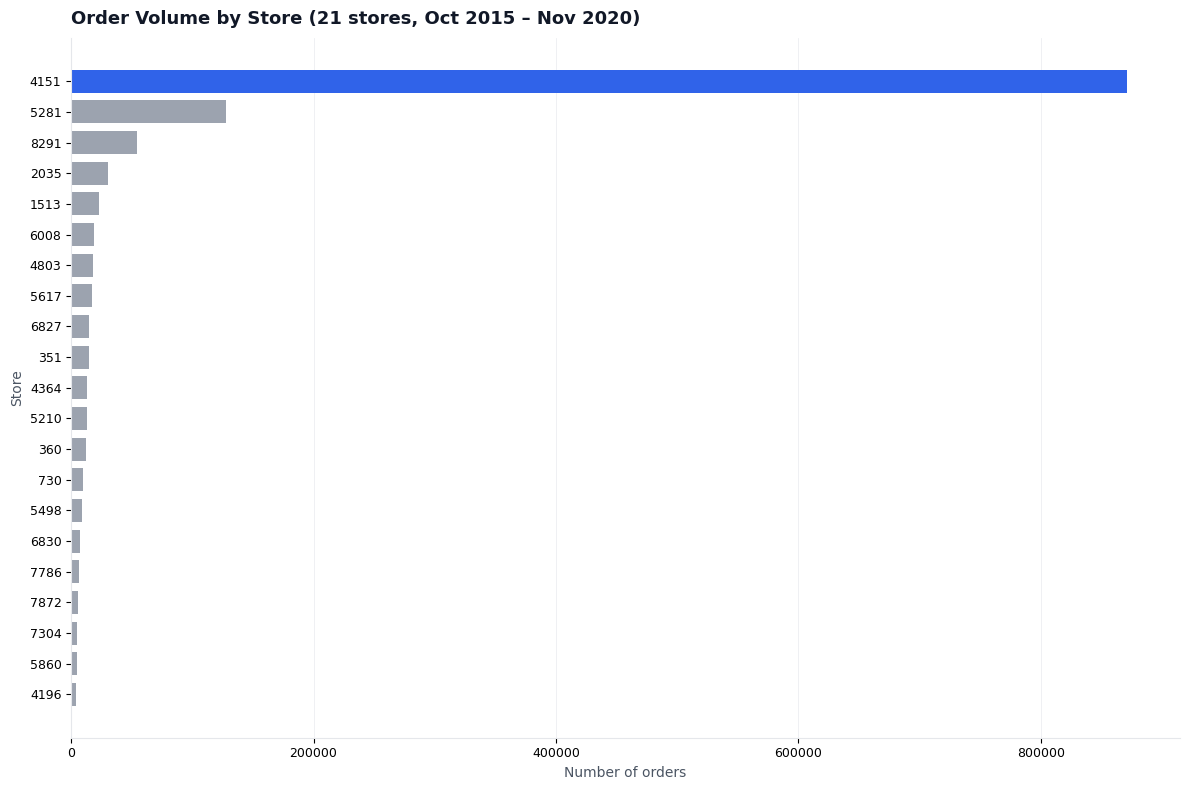

  ✓ Saved: charts/02_data_understanding/2_5_1_orders_by_store.png


In [ ]:
# Chart 1: Order Volume by Store
fig, ax = plt.subplots(figsize=(12, 8))
orders_sorted = store_df.sort_values('orders', ascending=True)
colors = [COLORS['primary'] if sid == 4151 else COLORS['light'] for sid in orders_sorted['id_store']]
ax.barh(orders_sorted['id_store'].astype(str), orders_sorted['orders'], color=colors, edgecolor='none', height=0.75)
ax.set_xlabel('Number of orders', color=COLORS['gray'])
ax.set_ylabel('Store', color=COLORS['gray'])
ax.set_title('Order Volume by Store (21 stores, Oct 2015 – Nov 2020)', color=COLORS['black'], loc='left', pad=10, fontweight='semibold')
ax.xaxis.grid(True, color=COLORS['grid'], alpha=0.7)
ax.set_axisbelow(True)
ax.spines['left'].set_color(COLORS['grid'])
ax.spines['bottom'].set_color(COLORS['grid'])
save_and_show(fig, '2_5_1_orders_by_store.png')

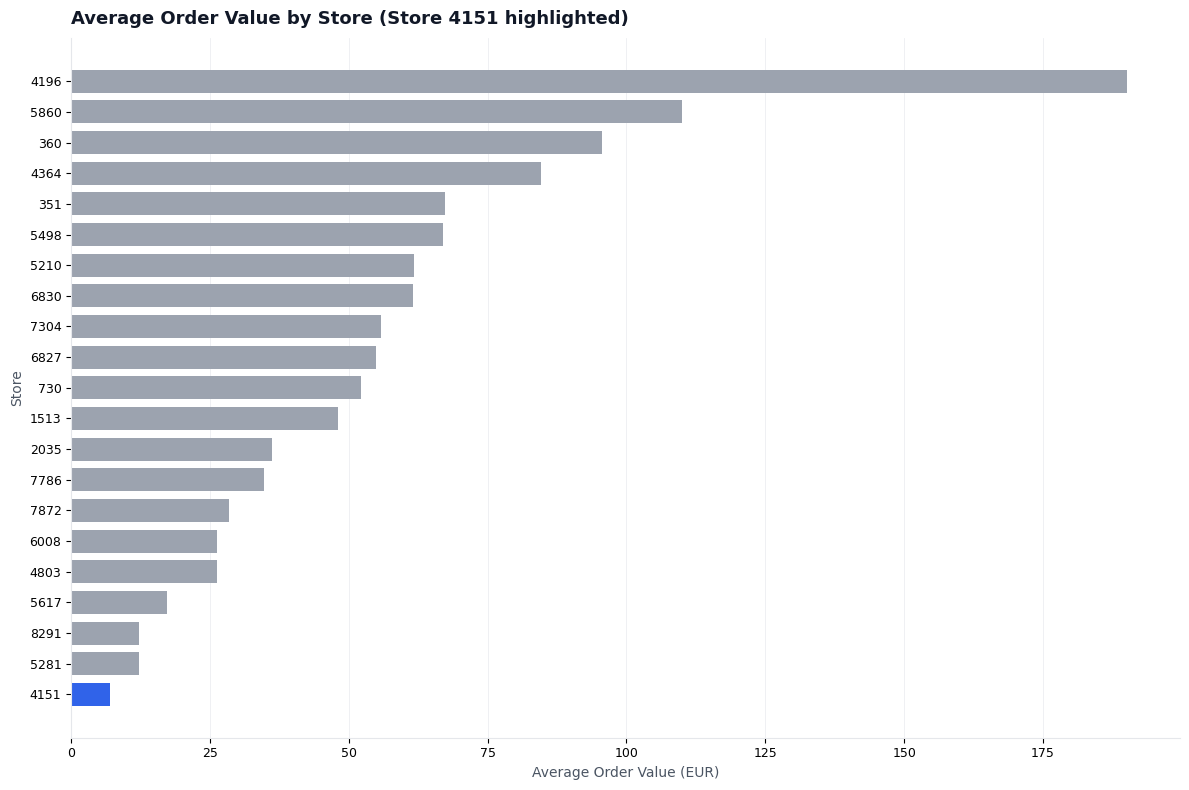

  ✓ Saved: charts/02_data_understanding/2_5_1_aov_by_store.png


In [ ]:
# Chart 2: Average Order Value by Store
fig, ax = plt.subplots(figsize=(12, 8))
aov_sorted = store_df.sort_values('avg_order_value', ascending=True)
colors = [COLORS['primary'] if sid == 4151 else COLORS['light'] for sid in aov_sorted['id_store']]
ax.barh(aov_sorted['id_store'].astype(str), aov_sorted['avg_order_value'], color=colors, edgecolor='none', height=0.75)
ax.set_xlabel('Average Order Value (EUR)', color=COLORS['gray'])
ax.set_ylabel('Store', color=COLORS['gray'])
ax.set_title('Average Order Value by Store (Store 4151 highlighted)', color=COLORS['black'], loc='left', pad=10, fontweight='semibold')
ax.xaxis.grid(True, color=COLORS['grid'], alpha=0.7)
ax.set_axisbelow(True)
ax.spines['left'].set_color(COLORS['grid'])
ax.spines['bottom'].set_color(COLORS['grid'])
save_and_show(fig, '2_5_1_aov_by_store.png')

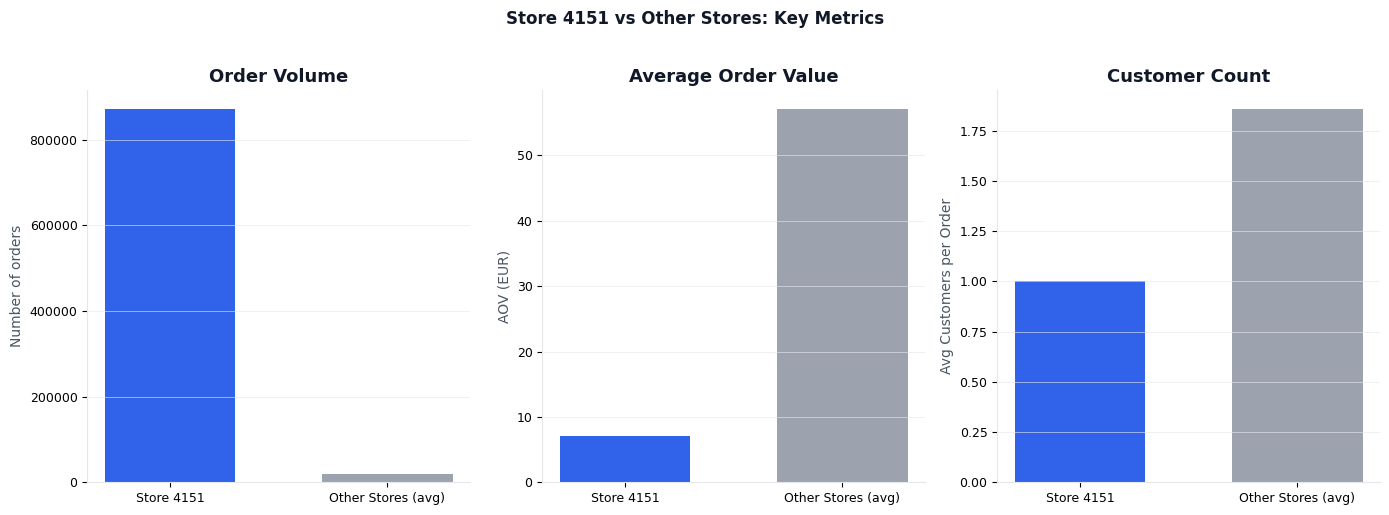

  ✓ Saved: charts/02_data_understanding/2_5_1_store_4151_vs_others.png


In [ ]:
# Chart 3: Store 4151 vs Other Stores
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
axes[0].bar(['Store 4151', 'Other Stores (avg)'], [store_4151['orders'], other_stores['orders'].mean()],
            color=[COLORS['primary'], COLORS['light']], edgecolor='none', width=0.6)
axes[0].set_ylabel('Number of orders', color=COLORS['gray'])
axes[0].set_title('Order Volume', color=COLORS['black'], fontweight='semibold')
axes[0].yaxis.grid(True, color=COLORS['grid'], alpha=0.7)
axes[0].set_ylim(0, None)
axes[0].spines['left'].set_color(COLORS['grid'])
axes[0].spines['bottom'].set_color(COLORS['grid'])
axes[1].bar(['Store 4151', 'Other Stores (avg)'], [store_4151['avg_order_value'], other_stores['avg_order_value'].mean()],
            color=[COLORS['primary'], COLORS['light']], edgecolor='none', width=0.6)
axes[1].set_ylabel('AOV (EUR)', color=COLORS['gray'])
axes[1].set_title('Average Order Value', color=COLORS['black'], fontweight='semibold')
axes[1].yaxis.grid(True, color=COLORS['grid'], alpha=0.7)
axes[1].set_ylim(0, None)
axes[1].spines['left'].set_color(COLORS['grid'])
axes[1].spines['bottom'].set_color(COLORS['grid'])
axes[2].bar(['Store 4151', 'Other Stores (avg)'], [store_4151['avg_customers'], other_stores['avg_customers'].mean()],
            color=[COLORS['primary'], COLORS['light']], edgecolor='none', width=0.6)
axes[2].set_ylabel('Avg Customers per Order', color=COLORS['gray'])
axes[2].set_title('Customer Count', color=COLORS['black'], fontweight='semibold')
axes[2].yaxis.grid(True, color=COLORS['grid'], alpha=0.7)
axes[2].set_ylim(0, None)
axes[2].spines['left'].set_color(COLORS['grid'])
axes[2].spines['bottom'].set_color(COLORS['grid'])
plt.suptitle('Store 4151 vs Other Stores: Key Metrics', color=COLORS['black'], fontweight='semibold', y=1.02)
save_and_show(fig, '2_5_1_store_4151_vs_others.png')

**Key Findings**
- Store 4151 dominates volume: 871,415 orders (68.02% of total)
- Store 4151 has lowest AOV: EUR 7.03 vs EUR 57.11 average for other stores
- High-volume ≠ high-value: the highest-volume store has the lowest average order value
- **Implication:** Store composition strongly affects aggregate metrics; store-level analysis is essential

Store 4151 also has a different product mix (PRESSION, WINES & CHAMPAGNES, SOFT, STRONG ALCOHOLS) and should not be treated as a typical store when interpreting overall trends.

## 2.5.2 Temporal Behaviour

### Context
Transaction activity shows clear variation over time — yearly, weekly, and hourly. Understanding these patterns is crucial for demand forecasting and operational planning.

### Key Questions
- How has order volume evolved over the observation period?
- Are there recurring weekly or hourly patterns?
- Do volume and value follow the same temporal patterns?

### Why This Matters
Temporal patterns provide analytical signals for forecasting and reveal operational insights about customer behaviour.

In [ ]:
query = '''
SELECT EXTRACT(YEAR FROM date_opened) AS year, COUNT(*) AS orders,
       ROUND(AVG(m_cached_price), 2) AS avg_order_value
FROM `le-wagon-da-502302.tiller.order_data`
WHERE date_opened IS NOT NULL
GROUP BY year
ORDER BY year
'''
temporal_yearly = run_query(query)
temporal_yearly

,year,orders,avg_order_value
0,2015,890,58.05
1,2016,20129,48.76
2,2017,61003,29.57
3,2018,428713,14.02
4,2019,564123,14.06
5,2020,206290,16.97


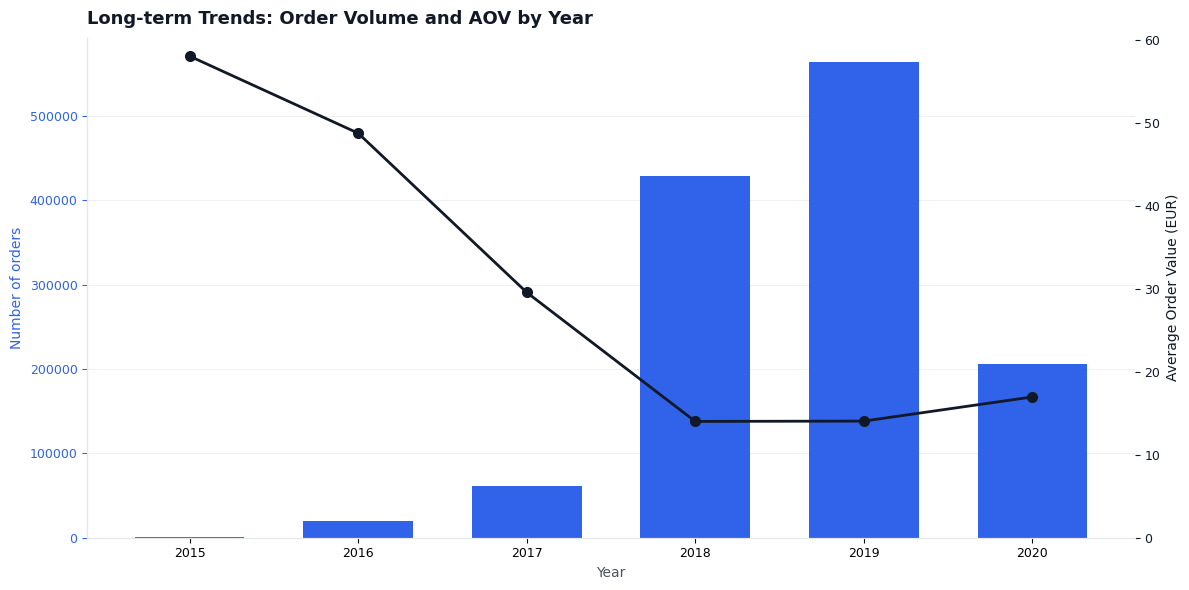

  ✓ Saved: charts/02_data_understanding/2_5_2_yearly_trend.png


In [ ]:
# Chart 4: Yearly trends — primary bars, black AOV line
fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.bar(temporal_yearly['year'].astype(str), temporal_yearly['orders'], color=COLORS['primary'], edgecolor='none', width=0.65)
ax1.set_xlabel('Year', color=COLORS['gray'])
ax1.set_ylabel('Number of orders', color=COLORS['primary'])
ax1.set_title('Long-term Trends: Order Volume and AOV by Year', color=COLORS['black'], loc='left', pad=10, fontweight='semibold')
ax1.yaxis.grid(True, color=COLORS['grid'], alpha=0.7)
ax1.set_axisbelow(True)
ax1.tick_params(axis='y', colors=COLORS['primary'])
ax1.spines['left'].set_color(COLORS['grid'])
ax1.spines['bottom'].set_color(COLORS['grid'])
ax2 = ax1.twinx()
ax2.spines['top'].set_visible(False)
ax2.plot(temporal_yearly['year'].astype(str), temporal_yearly['avg_order_value'], color=COLORS['black'], marker='o', linewidth=2, markersize=7)
ax2.set_ylabel('Average Order Value (EUR)', color=COLORS['black'])
ax2.tick_params(axis='y', colors=COLORS['black'])
ax2.set_ylim(0, None)
save_and_show(fig, '2_5_2_yearly_trend.png')

In [ ]:
query = '''
SELECT EXTRACT(DAYOFWEEK FROM date_opened) AS day_num,
       FORMAT_DATE('%A', date_opened) AS day_name,
       COUNT(*) AS orders, ROUND(AVG(m_cached_price), 2) AS avg_order_value
FROM `le-wagon-da-502302.tiller.order_data`
WHERE date_opened IS NOT NULL
GROUP BY day_num, day_name
ORDER BY day_num
'''
temporal_weekly = run_query(query)
temporal_weekly

,day_num,day_name,orders,avg_order_value
0,1,Sunday,168682,10.38
1,2,Monday,46079,27.44
2,3,Tuesday,68383,32.27
3,4,Wednesday,194719,16.34
4,5,Thursday,223696,16.09
5,6,Friday,275851,15.22
6,7,Saturday,303738,13.44


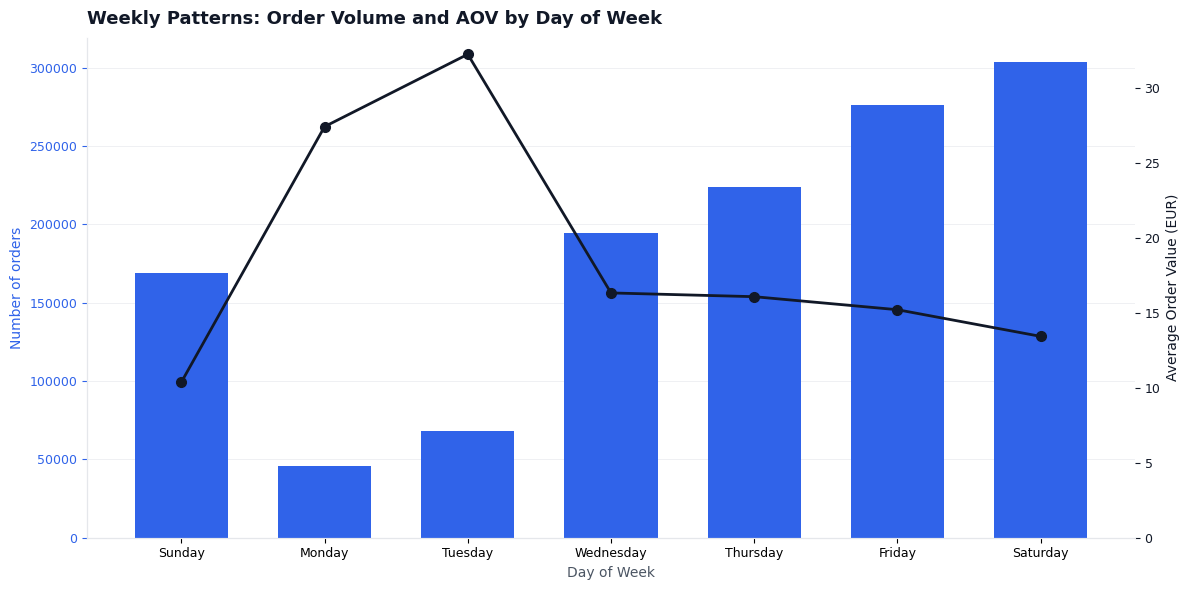

  ✓ Saved: charts/02_data_understanding/2_5_2_weekly_pattern.png


In [ ]:
# Chart 5: Weekly patterns
fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.bar(temporal_weekly['day_name'], temporal_weekly['orders'], color=COLORS['primary'], edgecolor='none', width=0.65)
ax1.set_xlabel('Day of Week', color=COLORS['gray'])
ax1.set_ylabel('Number of orders', color=COLORS['primary'])
ax1.set_title('Weekly Patterns: Order Volume and AOV by Day of Week', color=COLORS['black'], loc='left', pad=10, fontweight='semibold')
ax1.yaxis.grid(True, color=COLORS['grid'], alpha=0.7)
ax1.set_axisbelow(True)
ax1.tick_params(axis='y', colors=COLORS['primary'])
ax1.spines['left'].set_color(COLORS['grid'])
ax1.spines['bottom'].set_color(COLORS['grid'])
ax2 = ax1.twinx()
ax2.spines['top'].set_visible(False)
ax2.plot(range(len(temporal_weekly)), temporal_weekly['avg_order_value'], color=COLORS['black'], marker='o', linewidth=2, markersize=7)
ax2.set_ylabel('Average Order Value (EUR)', color=COLORS['black'])
ax2.tick_params(axis='y', colors=COLORS['black'])
ax2.set_ylim(0, None)
save_and_show(fig, '2_5_2_weekly_pattern.png')

In [ ]:
query = '''
SELECT EXTRACT(HOUR FROM date_opened) AS hour, COUNT(*) AS orders,
       ROUND(AVG(m_cached_price), 2) AS avg_order_value
FROM `le-wagon-da-502302.tiller.order_data`
WHERE date_opened IS NOT NULL
GROUP BY hour
ORDER BY hour
'''
temporal_hourly = run_query(query)
temporal_hourly

,hour,orders,avg_order_value
0,0,1533,37.16
1,1,623,54.86
2,2,175,30.55
3,3,150,42.08
4,4,89,52.95
5,5,88,52.27
6,6,635,12.21
7,7,5753,9.87
8,8,12564,12.49
9,9,18113,14.96


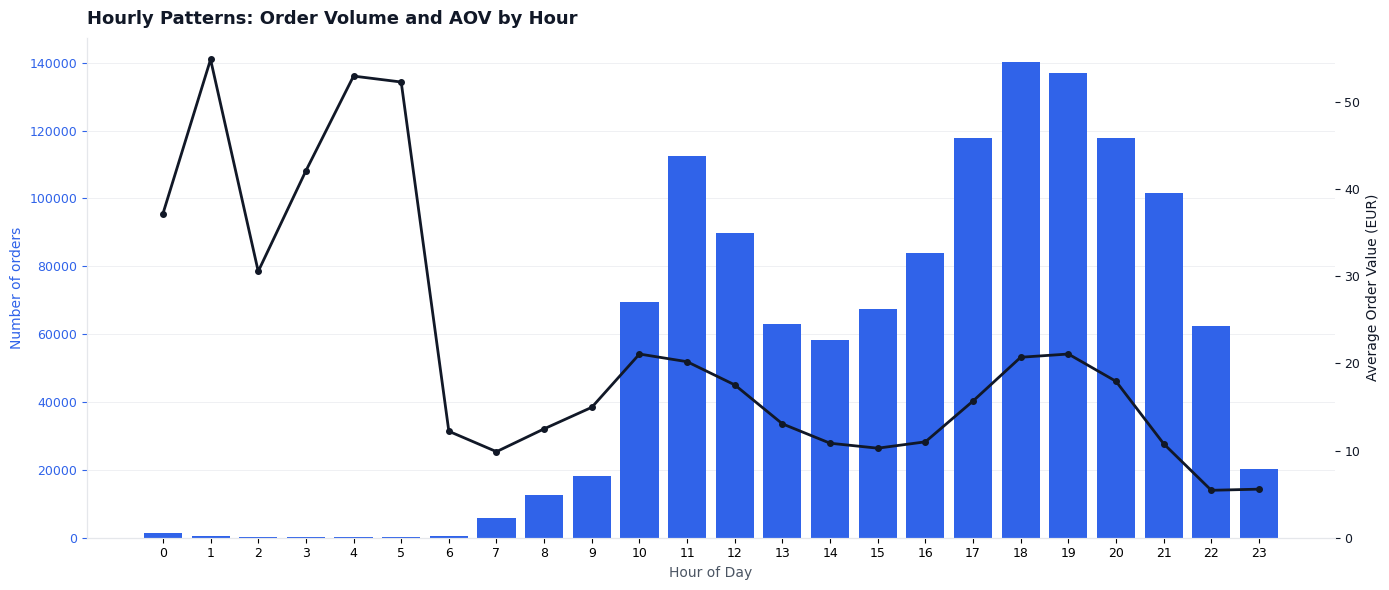

  ✓ Saved: charts/02_data_understanding/2_5_2_hourly_pattern.png


In [ ]:
# Chart 6: Hourly patterns
fig, ax1 = plt.subplots(figsize=(14, 6))
ax1.bar(temporal_hourly['hour'], temporal_hourly['orders'], color=COLORS['primary'], edgecolor='none', width=0.8)
ax1.set_xlabel('Hour of Day', color=COLORS['gray'])
ax1.set_ylabel('Number of orders', color=COLORS['primary'])
ax1.set_title('Hourly Patterns: Order Volume and AOV by Hour', color=COLORS['black'], loc='left', pad=10, fontweight='semibold')
ax1.yaxis.grid(True, color=COLORS['grid'], alpha=0.7)
ax1.set_axisbelow(True)
ax1.set_xticks(range(0, 24))
ax1.tick_params(axis='y', colors=COLORS['primary'])
ax1.spines['left'].set_color(COLORS['grid'])
ax1.spines['bottom'].set_color(COLORS['grid'])
ax2 = ax1.twinx()
ax2.spines['top'].set_visible(False)
ax2.plot(temporal_hourly['hour'], temporal_hourly['avg_order_value'], color=COLORS['black'], linewidth=2, marker='o', markersize=4)
ax2.set_ylabel('Average Order Value (EUR)', color=COLORS['black'])
ax2.tick_params(axis='y', colors=COLORS['black'])
ax2.set_ylim(0, None)
save_and_show(fig, '2_5_2_hourly_pattern.png')

**Key Findings**
- **Long-term trend:** Order volume increased substantially 2015→2019; AOV decreased (store composition / Store 4151 growth)
- **Weekly pattern:** Sunday highest volume (168,682 orders); weekday AOV varies independently of volume
- **Hourly pattern:** Lunch (11:00–13:00) and dinner (18:00–20:00) peaks
- **Implication:** Time-based features provide meaningful signals for forecasting and operational planning

## 2.5.3 Product and Category Behaviour

### Context
The order-line data contains 12,145 unique products and 456 raw categories (438 translated). Product activity is concentrated in relatively few categories, but taxonomy inconsistencies exist.

### Key Questions
- Which categories contribute most to order-line value?
- How concentrated is product activity?
- Are there taxonomy issues that would affect product analysis?

### Why This Matters
Understanding product mix and category concentration helps identify whether product/basket analysis is feasible and valuable.

In [ ]:
query = '''
SELECT dim_category, COUNT(*) AS order_lines,
       ROUND(SUM(m_total_price_inc_vat), 2) AS total_value
FROM `le-wagon-da-502302.tiller.order_line`
WHERE dim_category IS NOT NULL
GROUP BY dim_category
ORDER BY order_lines DESC
LIMIT 15
'''
category_dist = run_query(query)
category_dist

,dim_category,order_lines,total_value
0,CONSIGNE,1278896,-165030.00
1,PRESSION,513254,3619901.30
2,SOFT,236536,733093.25
3,EXPRESSIONS ESPRESSO,124811,504165.90
4,VINS & CHAMPAGNES,91470,741491.60
5,BIERES & CIDRES BOUTEILLES,73569,400305.05
6,Plats,66131,1191314.65
7,VARIOUS,57484,9340.06
8,ALCOOLS FORTS,55913,508200.50
9,Desserts,49365,333372.55


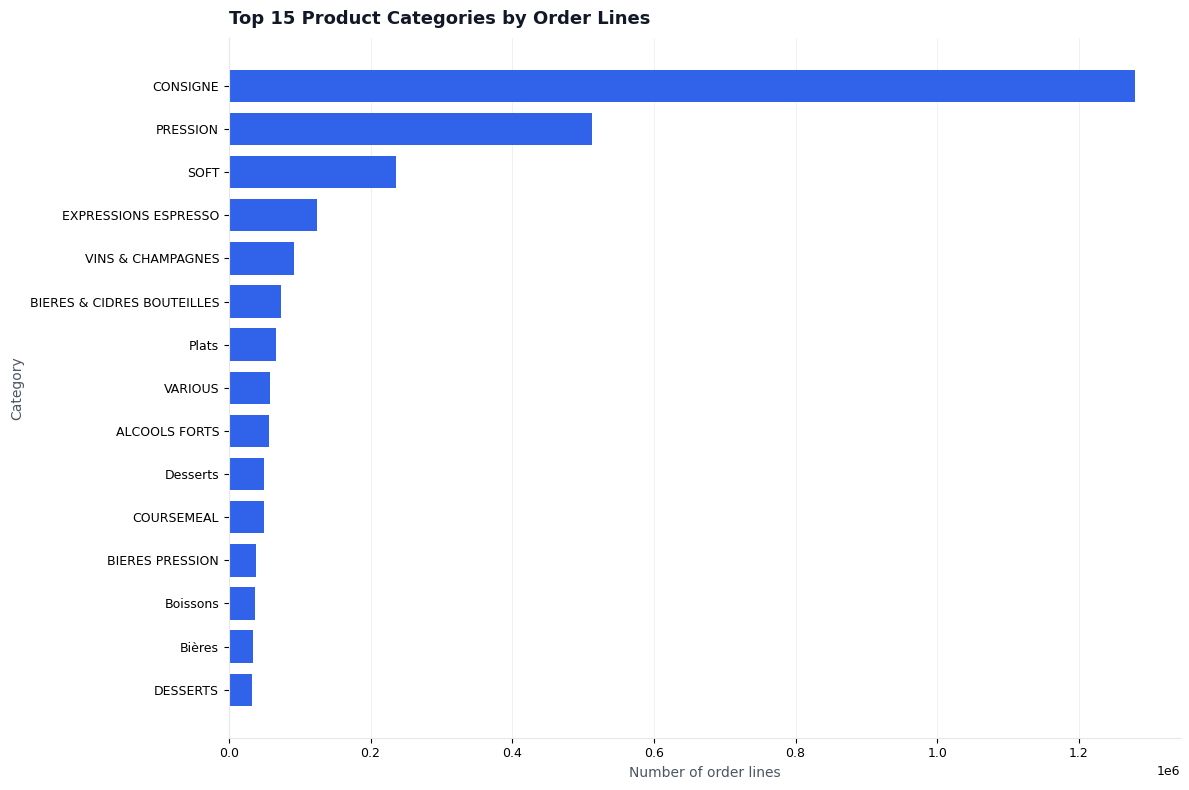

  ✓ Saved: charts/02_data_understanding/2_5_3_top_categories.png


In [ ]:
# Chart 7: Top categories by order lines
fig, ax = plt.subplots(figsize=(12, 8))
cat_sorted = category_dist.sort_values('order_lines', ascending=True)
ax.barh(cat_sorted['dim_category'], cat_sorted['order_lines'], color=COLORS['primary'], edgecolor='none', height=0.75)
ax.set_xlabel('Number of order lines', color=COLORS['gray'])
ax.set_ylabel('Category', color=COLORS['gray'])
ax.set_title('Top 15 Product Categories by Order Lines', color=COLORS['black'], loc='left', pad=10, fontweight='semibold')
ax.xaxis.grid(True, color=COLORS['grid'], alpha=0.7)
ax.set_axisbelow(True)
ax.spines['left'].set_color(COLORS['grid'])
ax.spines['bottom'].set_color(COLORS['grid'])
save_and_show(fig, '2_5_3_top_categories.png')

In [ ]:
query = '''
SELECT dim_category, COUNT(*) AS order_lines,
       ROUND(SUM(m_total_price_inc_vat), 2) AS total_value
FROM `le-wagon-da-502302.tiller.order_line`
WHERE dim_category IS NOT NULL
GROUP BY dim_category
ORDER BY total_value DESC
LIMIT 15
'''
category_value = run_query(query)
category_value

,dim_category,order_lines,total_value
0,PRESSION,513254,3619901.30
1,Plats,66131,1191314.65
2,COURSEMEAL,48876,793676.40
3,VINS & CHAMPAGNES,91470,741491.60
4,SOFT,236536,733093.25
5,PLATS,29588,544764.44
6,ALCOOLS FORTS,55913,508200.50
7,EXPRESSIONS ESPRESSO,124811,504165.90
8,vente directe,18888,459094.88
9,BIERES & CIDRES BOUTEILLES,73569,400305.05


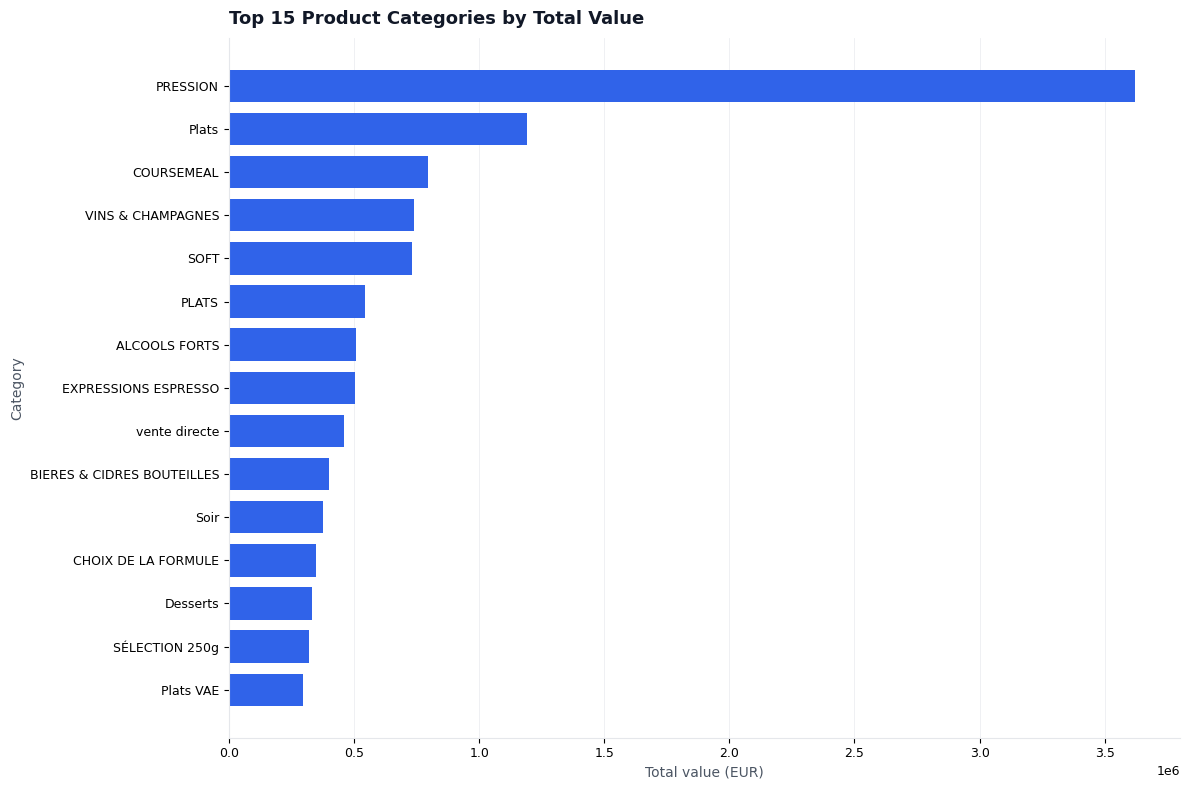

  ✓ Saved: charts/02_data_understanding/2_5_3_top_categories_value.png


In [ ]:
# Chart 8: Top categories by value
fig, ax = plt.subplots(figsize=(12, 8))
val_sorted = category_value.sort_values('total_value', ascending=True)
ax.barh(val_sorted['dim_category'], val_sorted['total_value'], color=COLORS['primary'], edgecolor='none', height=0.75)
ax.set_xlabel('Total value (EUR)', color=COLORS['gray'])
ax.set_ylabel('Category', color=COLORS['gray'])
ax.set_title('Top 15 Product Categories by Total Value', color=COLORS['black'], loc='left', pad=10, fontweight='semibold')
ax.xaxis.grid(True, color=COLORS['grid'], alpha=0.7)
ax.set_axisbelow(True)
ax.spines['left'].set_color(COLORS['grid'])
ax.spines['bottom'].set_color(COLORS['grid'])
save_and_show(fig, '2_5_3_top_categories_value.png')

**Key Findings**
- **High concentration:** PRESSION represents 17.8% of total order-line value
- **Taxonomy issues:** CONSIGNE (ORDER) is technical (~1.28M lines); language/spelling variants exist
- **12,145 products, 456 categories:** analytical potential, but taxonomy validation needed
- **Implication:** Product analysis is feasible; deeper basket work needs taxonomy cleaning

## 2.5.4 Transaction and Customer Economics

### Context
Order value varies substantially based on transaction composition. This section examines how the number of customers and items per order relates to order value.

### Key Questions
- How does order value vary with the number of customers?
- How does order value vary with the number of items?
- Are these relationships associations or causal?

### Why This Matters
Understanding what drives higher-value transactions can inform operational strategies and analytical priorities.

In [ ]:
query = '''
SELECT CASE
    WHEN m_nb_customer = 1 THEN '1 customer'
    WHEN m_nb_customer = 2 THEN '2 customers'
    WHEN m_nb_customer BETWEEN 3 AND 4 THEN '3-4 customers'
    ELSE '5+ customers'
  END AS customer_segment,
  COUNT(*) AS orders,
  ROUND(AVG(m_cached_price), 2) AS avg_order_value
FROM `le-wagon-da-502302.tiller.order_data`
WHERE m_nb_customer IS NOT NULL
GROUP BY customer_segment
ORDER BY MIN(m_nb_customer)
'''
customers_grouped = run_query(query)
customers_grouped

,customer_segment,orders,avg_order_value
0,5+ customers,29206,73.55
1,1 customer,1075499,9.96
2,2 customers,146588,32.25
3,3-4 customers,29855,90.12


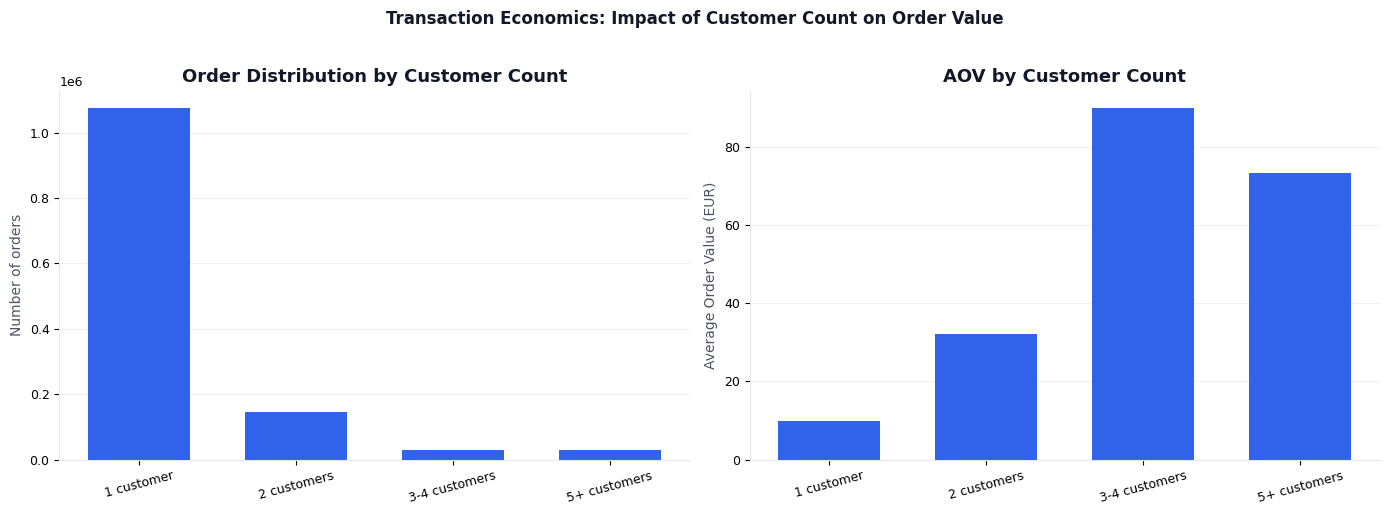

  ✓ Saved: charts/02_data_understanding/2_5_4_customers_per_order.png


In [ ]:
# Chart 9: Customers per order
cust_order = ['1 customer', '2 customers', '3-4 customers', '5+ customers']
customers_grouped = (
    customers_grouped.set_index('customer_segment')
    .reindex([c for c in cust_order if c in customers_grouped['customer_segment'].values])
    .reset_index()
)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(customers_grouped['customer_segment'], customers_grouped['orders'], color=COLORS['primary'], edgecolor='none', width=0.65)
axes[0].set_ylabel('Number of orders', color=COLORS['gray'])
axes[0].set_title('Order Distribution by Customer Count', color=COLORS['black'], fontweight='semibold')
axes[0].yaxis.grid(True, color=COLORS['grid'], alpha=0.7)
axes[0].set_axisbelow(True)
axes[0].set_ylim(0, None)
axes[0].tick_params(axis='x', rotation=15)
axes[0].spines['left'].set_color(COLORS['grid'])
axes[0].spines['bottom'].set_color(COLORS['grid'])
axes[1].bar(customers_grouped['customer_segment'], customers_grouped['avg_order_value'], color=COLORS['primary'], edgecolor='none', width=0.65)
axes[1].set_ylabel('Average Order Value (EUR)', color=COLORS['gray'])
axes[1].set_title('AOV by Customer Count', color=COLORS['black'], fontweight='semibold')
axes[1].yaxis.grid(True, color=COLORS['grid'], alpha=0.7)
axes[1].set_axisbelow(True)
axes[1].set_ylim(0, None)
axes[1].tick_params(axis='x', rotation=15)
axes[1].spines['left'].set_color(COLORS['grid'])
axes[1].spines['bottom'].set_color(COLORS['grid'])
plt.suptitle('Transaction Economics: Impact of Customer Count on Order Value', color=COLORS['black'], fontweight='semibold', y=1.02)
save_and_show(fig, '2_5_4_customers_per_order.png')

In [ ]:
query = '''
SELECT CASE
    WHEN items_per_order BETWEEN 1 AND 2 THEN '1-2 items'
    WHEN items_per_order BETWEEN 3 AND 5 THEN '3-5 items'
    WHEN items_per_order BETWEEN 6 AND 10 THEN '6-10 items'
    ELSE '11+ items'
  END AS item_segment,
  COUNT(*) AS orders,
  ROUND(AVG(order_value), 2) AS avg_order_value
FROM (
  SELECT od.id_order, od.m_cached_price AS order_value, COUNT(ol.id_order_line) AS items_per_order
  FROM `le-wagon-da-502302.tiller.order_data` od
  JOIN `le-wagon-da-502302.tiller.order_line` ol ON od.id_order = ol.id_order
  GROUP BY od.id_order, od.m_cached_price
)
GROUP BY item_segment
ORDER BY MIN(items_per_order)
'''
items_grouped = run_query(query)
items_grouped

,item_segment,orders,avg_order_value
0,1-2 items,754111,6.96
1,3-5 items,369994,16.92
2,6-10 items,124235,42.71
3,11+ items,31150,111.24


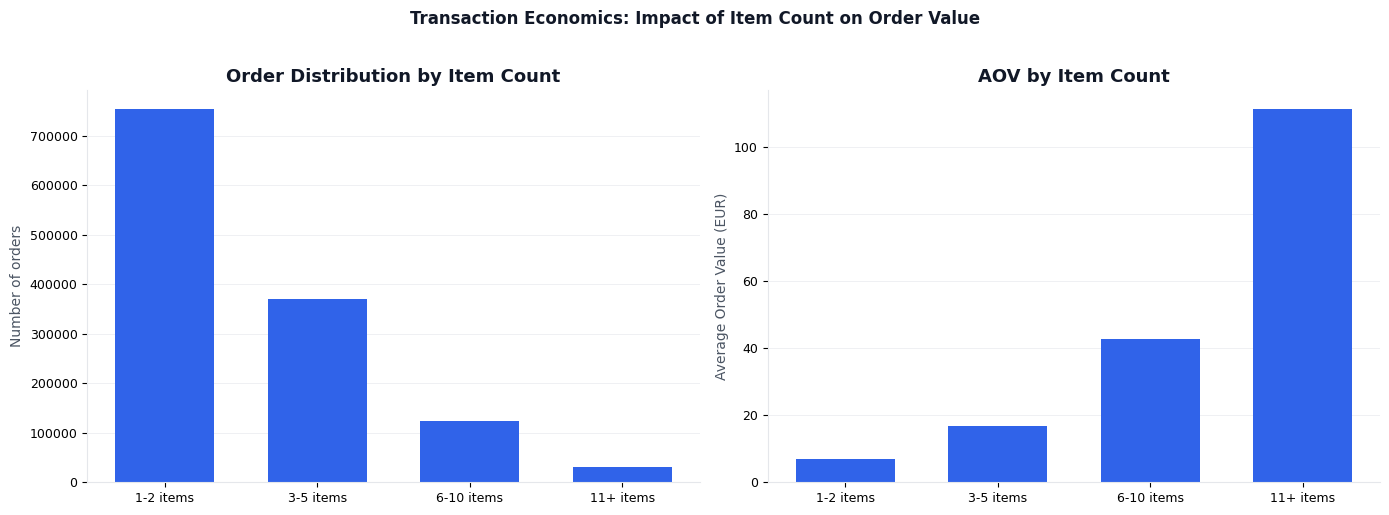

  ✓ Saved: charts/02_data_understanding/2_5_4_items_per_order.png


In [ ]:
# Chart 10: Items per order
item_order = ['1-2 items', '3-5 items', '6-10 items', '11+ items']
items_grouped = (
    items_grouped.set_index('item_segment')
    .reindex([c for c in item_order if c in items_grouped['item_segment'].values])
    .reset_index()
)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(items_grouped['item_segment'], items_grouped['orders'], color=COLORS['primary'], edgecolor='none', width=0.65)
axes[0].set_ylabel('Number of orders', color=COLORS['gray'])
axes[0].set_title('Order Distribution by Item Count', color=COLORS['black'], fontweight='semibold')
axes[0].yaxis.grid(True, color=COLORS['grid'], alpha=0.7)
axes[0].set_axisbelow(True)
axes[0].set_ylim(0, None)
axes[0].spines['left'].set_color(COLORS['grid'])
axes[0].spines['bottom'].set_color(COLORS['grid'])
axes[1].bar(items_grouped['item_segment'], items_grouped['avg_order_value'], color=COLORS['primary'], edgecolor='none', width=0.65)
axes[1].set_ylabel('Average Order Value (EUR)', color=COLORS['gray'])
axes[1].set_title('AOV by Item Count', color=COLORS['black'], fontweight='semibold')
axes[1].yaxis.grid(True, color=COLORS['grid'], alpha=0.7)
axes[1].set_axisbelow(True)
axes[1].set_ylim(0, None)
axes[1].spines['left'].set_color(COLORS['grid'])
axes[1].spines['bottom'].set_color(COLORS['grid'])
plt.suptitle('Transaction Economics: Impact of Item Count on Order Value', color=COLORS['black'], fontweight='semibold', y=1.02)
save_and_show(fig, '2_5_4_items_per_order.png')

**Key Findings**
- Strong positive association: more customers/items → substantially higher order values
- Customer segments: EUR 9.96 (1) → 32.25 (2) → 90.12 (3–4) → 73.55 (5+)
- Item segments: EUR 6.96 (1–2) → 16.92 (3–5) → 42.71 (6–10) → 111.24 (11+)
- **Important:** associations, not causal relationships
- **Implication:** transaction composition is a meaningful signal for order-value analysis

## 2.5.5 Payment and Operational Behaviour

### Context
The dataset contains information about payment methods, order sources, and operational dimensions. This section examines payment behaviour and identifies financial anomalies.

### Key Questions
- What payment methods are most common?
- How do order sources differ in volume and value?
- What proportion of transactions have negative values?

### Why This Matters
Payment behaviour provides contextual understanding; financial anomalies require careful interpretation in analysis.

In [ ]:
query = '''
SELECT dim_type, COUNT(*) AS payments,
       ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM `le-wagon-da-502302.tiller.payment_data`), 2) AS pct_of_total
FROM `le-wagon-da-502302.tiller.payment_data`
WHERE dim_type IS NOT NULL
GROUP BY dim_type
ORDER BY payments DESC
'''
payment_dist = run_query(query)
payment_dist.head(10)

,dim_type,payments,pct_of_total
0,CARD,728607,51.92
1,CASH,615195,43.84
2,TICKET_RESTAURANT,36557,2.61
3,FIVORY,7436,0.53
4,CREDIT_NOTE,5574,0.40
5,CB_Sans_Contact,3832,0.27
6,SUMUP,1382,0.10
7,BANK_CHECK,1099,0.08
8,VOUCHER,963,0.07
9,AMERICAN_EXPRESS,772,0.06


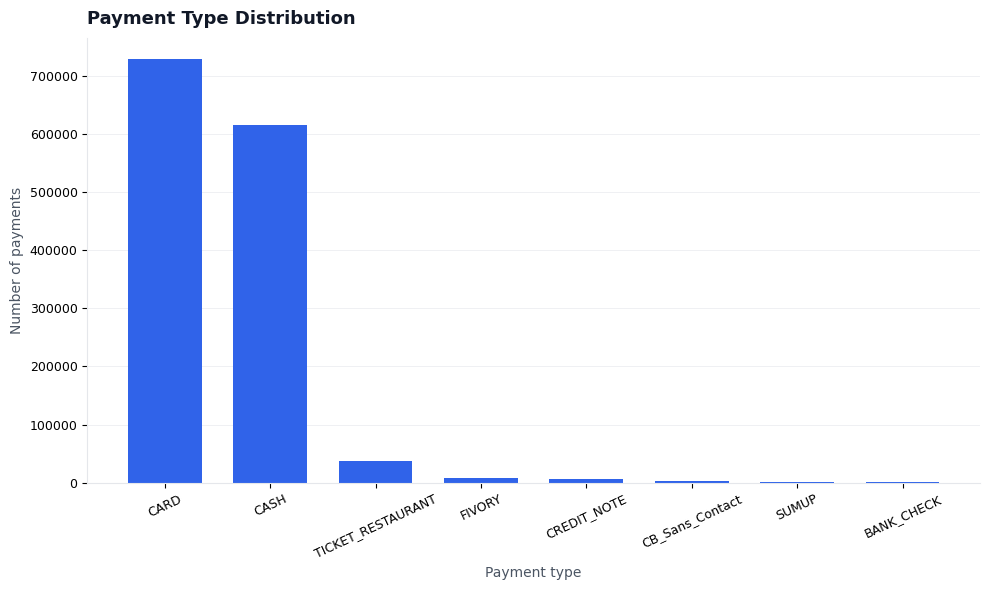

  ✓ Saved: charts/02_data_understanding/2_5_5_payment_types.png


In [ ]:
# Chart 11: Payment types
fig, ax = plt.subplots(figsize=(10, 6))
top_pay = payment_dist.head(8)
ax.bar(top_pay['dim_type'], top_pay['payments'], color=COLORS['primary'], edgecolor='none', width=0.7)
ax.set_ylabel('Number of payments', color=COLORS['gray'])
ax.set_xlabel('Payment type', color=COLORS['gray'])
ax.set_title('Payment Type Distribution', color=COLORS['black'], loc='left', pad=10, fontweight='semibold')
ax.yaxis.grid(True, color=COLORS['grid'], alpha=0.7)
ax.set_axisbelow(True)
ax.set_ylim(0, None)
ax.tick_params(axis='x', rotation=25)
ax.spines['left'].set_color(COLORS['grid'])
ax.spines['bottom'].set_color(COLORS['grid'])
save_and_show(fig, '2_5_5_payment_types.png')

In [ ]:
query = '''
SELECT dim_source, COUNT(*) AS orders,
       ROUND(AVG(m_cached_price), 2) AS avg_order_value
FROM `le-wagon-da-502302.tiller.order_data`
WHERE dim_source IS NOT NULL
GROUP BY dim_source
ORDER BY orders DESC
'''
order_source = run_query(query)
order_source

,dim_source,orders,avg_order_value
0,Tiller iPAD,1122780,14.17
1,tiller-order,100879,23.47
2,LAFOURCHETTE,715,9.27
3,Tiller iPod,9,39.44
4,ZENCHEF,6,83.37


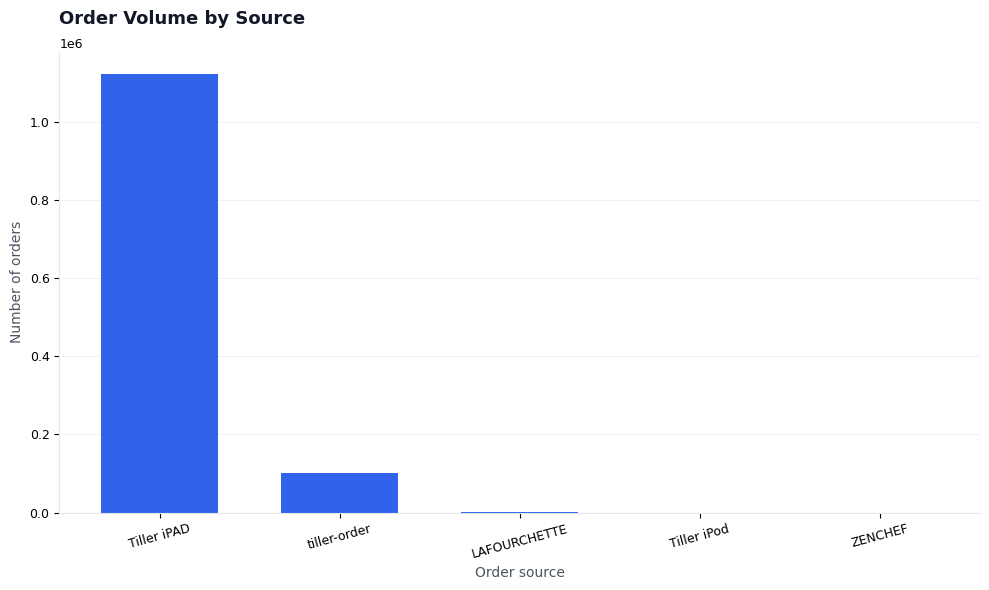

  ✓ Saved: charts/02_data_understanding/2_5_5_order_sources.png


In [ ]:
# Chart 12: Order sources
fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(order_source['dim_source'], order_source['orders'], color=COLORS['primary'], edgecolor='none', width=0.65)
ax.set_ylabel('Number of orders', color=COLORS['gray'])
ax.set_xlabel('Order source', color=COLORS['gray'])
ax.set_title('Order Volume by Source', color=COLORS['black'], loc='left', pad=10, fontweight='semibold')
ax.yaxis.grid(True, color=COLORS['grid'], alpha=0.7)
ax.set_axisbelow(True)
ax.set_ylim(0, None)
ax.tick_params(axis='x', rotation=15)
ax.spines['left'].set_color(COLORS['grid'])
ax.spines['bottom'].set_color(COLORS['grid'])
save_and_show(fig, '2_5_5_order_sources.png')

In [ ]:
anomalies_orders = run_query('''
  SELECT 'Orders' AS metric,
    SUM(CASE WHEN m_cached_price < 0 THEN 1 ELSE 0 END) * 100.0 / COUNT(*) AS pct
  FROM `le-wagon-da-502302.tiller.order_data`
''')
anomalies_lines = run_query('''
  SELECT 'Order Lines' AS metric,
    SUM(CASE WHEN m_total_price_inc_vat < 0 THEN 1 ELSE 0 END) * 100.0 / COUNT(*) AS pct
  FROM `le-wagon-da-502302.tiller.order_line`
''')
anomalies_payments = run_query('''
  SELECT 'Payments' AS metric,
    SUM(CASE WHEN m_amount < 0 THEN 1 ELSE 0 END) * 100.0 / COUNT(*) AS pct
  FROM `le-wagon-da-502302.tiller.payment_data`
''')
print(f"Negative order values: {anomalies_orders['pct'].iloc[0]:.2f}%")
print(f"Negative order-line values: {anomalies_lines['pct'].iloc[0]:.2f}%")
print(f"Negative payment amounts: {anomalies_payments['pct'].iloc[0]:.2f}%")

Negative order values: 20.56%
Negative order-line values: 17.12%
Negative payment amounts: 20.48%


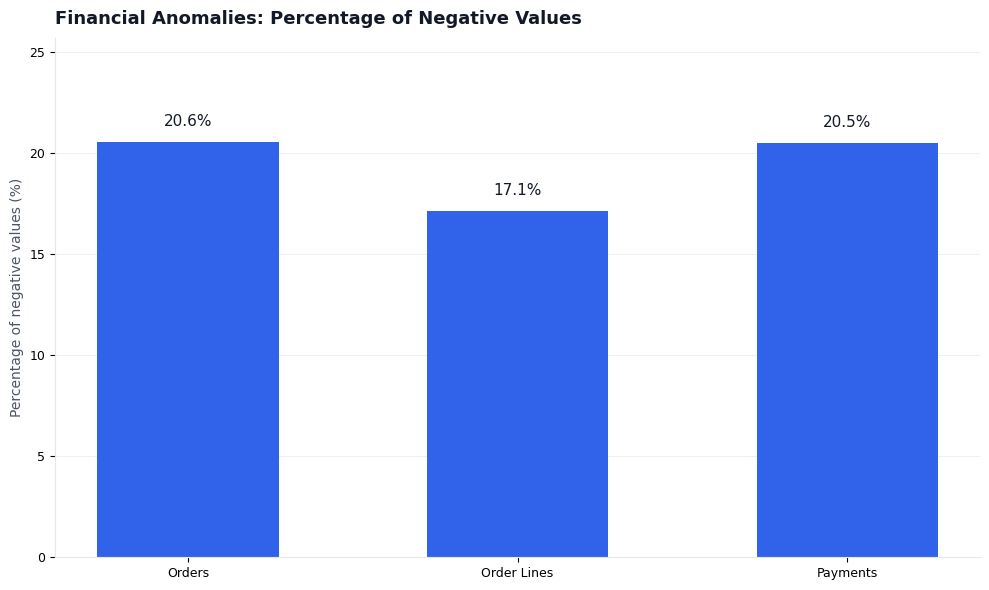

  ✓ Saved: charts/02_data_understanding/2_5_5_financial_anomalies.png


In [ ]:
# Chart 13: Financial anomalies — primary blue (not red)
fig, ax = plt.subplots(figsize=(10, 6))
metrics = ['Orders', 'Order Lines', 'Payments']
pct_negative = [
    anomalies_orders['pct'].iloc[0],
    anomalies_lines['pct'].iloc[0],
    anomalies_payments['pct'].iloc[0],
]
ax.bar(metrics, pct_negative, color=COLORS['primary'], edgecolor='none', width=0.55)
ax.set_ylabel('Percentage of negative values (%)', color=COLORS['gray'])
ax.set_title('Financial Anomalies: Percentage of Negative Values', color=COLORS['black'], loc='left', pad=10, fontweight='semibold')
ax.yaxis.grid(True, color=COLORS['grid'], alpha=0.7)
ax.set_axisbelow(True)
ax.set_ylim(0, max(pct_negative) * 1.25)
for i, v in enumerate(pct_negative):
    ax.text(i, v + 0.8, f'{v:.1f}%', ha='center', fontsize=11, color=COLORS['black'])
ax.spines['left'].set_color(COLORS['grid'])
ax.spines['bottom'].set_color(COLORS['grid'])
save_and_show(fig, '2_5_5_financial_anomalies.png')

**Key Findings**
- **Payment concentration:** CARD ~52%, CASH ~44%; other methods marginal
- **Order sources:** Tiller iPAD primary; tiller-order higher AOV
- **Financial anomalies:** ~20% negative values across orders / lines / payments — not automatically errors
- **Implication:** payment behaviour is useful context; anomalies need careful interpretation

---

## Phase 2.5 Summary

| Dimension | Key Insight |
|-----------|-------------|
| Store-level | Store 4151 = 68% of orders but lowest AOV (EUR 7.03); aggregate metrics strongly influenced by store composition |
| Temporal | Clear yearly, weekly, hourly patterns; Sunday highest volume; lunch/dinner peaks |
| Product/Category | High concentration (PRESSION 17.8%); taxonomy requires validation before deep basket analysis |
| Transaction Economics | Strong positive association: more customers/items → higher AOV (EUR 6.96 → 111.24) |
| Payment/Operational | CARD 52%, CASH 44%; 20%+ negative values (not necessarily errors) |